# E1 213 Pattern Recognition and Neural Network - Assignment 3
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from torch import nn
import os
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from sklearn.metrics import adjusted_rand_score
from torchvision.models import inception_v3, Inception_V3_Weights

from src import *

### **Phase 1**: Tree Ensembles & Boosting (Air Quality Data)

In [5]:
DATA_DIR = "/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data"
LABEL_COL = "pm2_5"
FEATURE_COL = "pm10"
ALL_FEATURE_COL = ["pm10", "no2", "so2", "co", "o3","nh3","no"]

df = pd.read_csv(os.path.join(DATA_DIR, "delhi_aqi.csv"))

#### **Problem 1.1**: Information Gain from scratch

In [8]:
label = np.array(df[LABEL_COL], dtype=np.float32)
label = np.where(label > 200, 1, 0)
feature = np.array(df[FEATURE_COL], dtype=np.float32)

rf = RandomForest()
threshold, gini_gain = rf.best_split_for_single_feature(feature, label)
print(f"Best threshold: {threshold}, Gini Gain: {gini_gain}")

Best threshold: 246.20575758450497, Gini Gain: 0.39669634467851095


#### **Problem 1.2**: Random Forest

In [11]:
np.random.seed(42)

label = np.array(df[LABEL_COL], dtype=np.float32)
label = np.where(label > 200, 1, 0)
feature = np.array(df[ALL_FEATURE_COL], dtype=np.float32)

N = np.random.permutation(len(feature))

train_idx = N[:int(0.7*len(feature))]
val_idx = N[int(0.7*len(feature)):int(0.85*len(feature))]
test_idx = N[int(0.85*len(feature)):]

X_train, y_train = feature[train_idx], label[train_idx]
X_val, y_val = feature[val_idx], label[val_idx]
X_test, y_test = feature[test_idx], label[test_idx]
rf = RandomForest(n_trees= 100, max_depth=2)

print("Training Random Forest...")
rf.fit(X_train, y_train)

print("Evaluating on validation and test sets...")
val_preds = rf.predict_forest(X_val)
test_preds = rf.predict_forest(X_test)
val_acc = np.mean(val_preds == y_val)
test_acc = np.mean(test_preds == y_test)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Random Forest...
Evaluating on validation and test sets...
Validation Accuracy: 0.9567
Test Accuracy: 0.9556


#### **Phase 1.3**: Adaboost Sample Reweighting

Training AdaBoost...


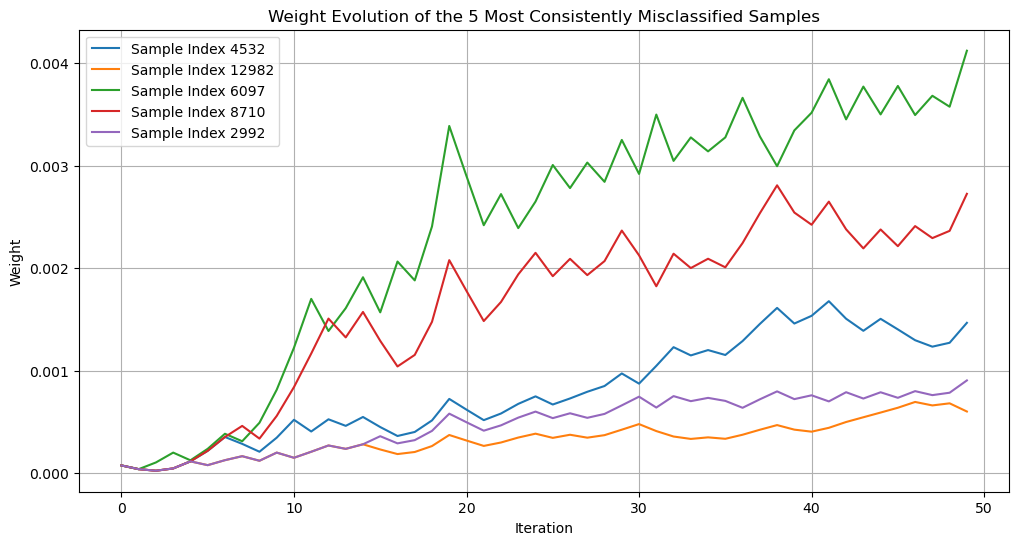

Evaluating on validation and test sets...
Validation Accuracy: 0.9702
Test Accuracy: 0.9691


In [ ]:
np.random.seed(42)

label = np.array(df[LABEL_COL], dtype=np.float32)
label = np.where(label > 200, 1, 0)
feature = np.array(df[ALL_FEATURE_COL], dtype=np.float32)

N = np.random.permutation(len(feature))

train_idx = N[:int(0.7*len(feature))]
val_idx = N[int(0.7*len(feature)):int(0.85*len(feature))]
test_idx = N[int(0.85*len(feature)):]

X_train, y_train = feature[train_idx], label[train_idx]
X_val, y_val = feature[val_idx], label[val_idx]
X_test, y_test = feature[test_idx], label[test_idx]
ad = adaboost(n_trees= 50, max_depth=2)

print("Training AdaBoost...")
weight_track, misclassification_track_idx = ad.fit(X_train, y_train)

weight_track = np.array(weight_track)
most_five_consistently_misclassified_idx = np.bincount(np.concatenate(misclassification_track_idx)).argsort()[-5:]
weight_track_for_most_five_consistently_misclassified_idx = [weight_track[i][most_five_consistently_misclassified_idx] for i in range(len(weight_track))]
weight_track_for_most_five_consistently_misclassified_idx = np.array(weight_track_for_most_five_consistently_misclassified_idx)

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.plot(weight_track_for_most_five_consistently_misclassified_idx[:, i], label=f'Sample Index {most_five_consistently_misclassified_idx[i]}')
plt.xlabel('Iteration')
plt.ylabel('Weight')
plt.title('Weight Evolution of the 5 Most Consistently Misclassified Samples')
plt.legend()
plt.grid()
plt.savefig("P01_3.png")
plt.show()

print("Evaluating on validation and test sets...")
val_preds = ad.predict_adaboost(X_val)
test_preds = ad.predict_adaboost(X_test)
val_acc = np.mean(val_preds == y_val)
test_acc = np.mean(test_preds == y_test)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

#### **Phase 1.4**: Gradient Boosting Residuals (Regression)

Training Gradient Boosted Regressor...
Evaluating on validation and test sets...
Validation MSE: 906.3695
Test MSE: 901.9108
Residual Variances across iterations:


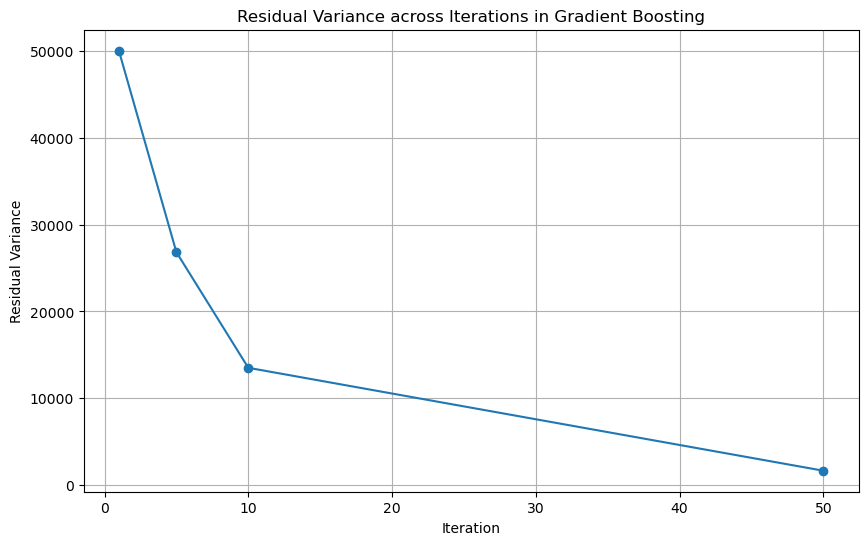

In [6]:
np.random.seed(42)

label = np.array(df[LABEL_COL], dtype=np.float32)
feature = np.array(df[ALL_FEATURE_COL], dtype=np.float32)

N = np.random.permutation(len(feature))

train_idx = N[:int(0.7*len(feature))]
val_idx = N[int(0.7*len(feature)):int(0.85*len(feature))]
test_idx = N[int(0.85*len(feature)):]

X_train, y_train = feature[train_idx], label[train_idx]
X_val, y_val = feature[val_idx], label[val_idx]
X_test, y_test = feature[test_idx], label[test_idx]

gbm = GradientBoostedRegressor(n_trees= 100, max_depth=2)

print("Training Gradient Boosted Regressor...")
residual_variances = gbm.fit(X_train, y_train)
print("Evaluating on validation and test sets...")
val_preds = gbm.predict_gradient_boosting(X_val)
test_preds = gbm.predict_gradient_boosting(X_test)
val_mse = np.mean((val_preds - y_val) ** 2)
test_mse = np.mean((test_preds - y_test) ** 2)
print(f"Validation MSE: {val_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

print("Residual Variances across iterations:")
plt.figure(figsize=(10, 6))
plt.plot(residual_variances.keys(), residual_variances.values(), marker='o')
plt.xlabel('Iteration')     
plt.ylabel('Residual Variance')
plt.title('Residual Variance across Iterations in Gradient Boosting')
plt.grid()
plt.savefig('P01_4.png')
plt.show()  

### **Phase 2**: Subspace & Clustering (Air Quality & PlantVillage)

In [2]:
DATA_DIR = "/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data"
FEATURE_COL = "pm10"
ALL_FEATURE_COL = ["pm10", "no2", "so2", "co", "o3","nh3","no","pm2_5"]

df = pd.read_csv(os.path.join(DATA_DIR, "delhi_aqi.csv"))

transform = transforms.Resize((128, 128))
plantvillage = PlantVillageDataset(os.path.join(DATA_DIR, 'plantvillage_dataset/segmented'), transform=transform)

#### **Phase 2.5**: PCA vs Linear Autoencoders

In [ ]:
X = np.array(df[ALL_FEATURE_COL], dtype=np.float32)
X_standardized = (X - X.mean(axis=0)) / X.std(axis=0)

print("Performing PCA...")
pca = PCA(explained_variance_threshold= 0.95)
X_reduced = pca.fit_transform(X_standardized)
X_reconstucted_pca = pca.inverse_transform(X_reduced)
print("PCA Number of Components:", pca.n_components)

print("Training Autoencoder...")
loss_fn = nn.MSELoss()
autoencoder = LinearAutoEncoder(input_dim=X.shape[1], latent_dim=X_reduced.shape[1])
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.01)

X_dataset = AQIDataset(X_standardized)
X_dataloader = DataLoader(X_dataset, batch_size= 32)
num_epochs = 50

unsupervised_train_loop(X_dataloader, autoencoder, loss_fn, optimizer, num_epochs)

X_reconstructed_ae = autoencoder(torch.from_numpy(X_standardized).to(device)).cpu().detach().numpy()

print("PCA Reconstruction MSE:", loss_fn(torch.from_numpy(X_reconstucted_pca), torch.from_numpy(X_standardized)).item())
print("Autoencoder Reconstruction MSE:", loss_fn(torch.from_numpy(X_reconstructed_ae), torch.from_numpy(X_standardized)).item())


Performing PCA...
PCA Number of Components: 4
Training Autoencoder...
Epoch 10/50, Train Loss: 0.0497
Epoch 20/50, Train Loss: 0.0538
Epoch 30/50, Train Loss: 0.0512
Epoch 40/50, Train Loss: 0.0508
Epoch 50/50, Train Loss: 0.0500
PCA Reconstruction MSE: 0.04692619666457176
Autoencoder Reconstruction MSE: 0.05455010011792183


#### **Phase 2.6**: GMM Latent Clustering

In [ ]:
np.random.seed(15)

model_CNN = ownCNN(128, len(plantvillage.class_to_idx)).to(device)

model_CNN.load_state_dict(torch.load("cnn_model_weights.pth", map_location=device))

model_CNN.fc = nn.ModuleList(list(model_CNN.fc)[:-1])
model_CNN.eval()

# Extract features from the full validation set
pv_loader = DataLoader(plantvillage, batch_size=32, shuffle=False)
all_features, all_labels = [], []

print("Getting Feature from CNN...")
with torch.no_grad():
    for X, y in pv_loader:
        X = X.to(device)
        features = model_CNN(X).cpu().numpy()
        all_features.append(features)
        all_labels.append(y.numpy())

all_features = np.concatenate(all_features, axis=0)
all_labels   = np.concatenate(all_labels,   axis=0)

# Fit GMM with K = number of disease classes
print("Fitting GMM ...")
n_classes = len(plantvillage.class_to_idx)
gmm = gaussian_mixture(all_features, K=n_classes)
gmm.fit(K=n_classes, iter=10)

# Cluster assignments
cluster_assignments = gmm.transform(all_features)

ari = adjusted_rand_score(all_labels, cluster_assignments)
print(f'ARI: {ari:.4f}')

Getting Feature from CNN...
Fitting GMM ...
ARI: 0.2808


### **Phase 3**: Deep Generative Models (PlantVillage & APTOS)

In [ ]:
DATA_DIR = "/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data"
CSV_FILE_PATH = os.path.join(DATA_DIR, 'aptos2019-blindness-detection/train.csv')
ROOT_DIR_PATH = os.path.join(DATA_DIR, 'aptos2019-blindness-detection/train_images')

transform = transforms.Resize((128, 128))
plantvillage = PlantVillageDataset(os.path.join(DATA_DIR, 'plantvillage_dataset/segmented'), transform=transform)

aptos_transform = transforms.Compose([transforms.Resize((299, 299)),])
aptos = AptosDatasetClass4(CSV_FILE_PATH, ROOT_DIR_PATH, transform = aptos_transform)

aptos_gan_transform = transforms.Resize((128, 128))
aptos_gan = AptosDatasetClass4(CSV_FILE_PATH, ROOT_DIR_PATH, transform=aptos_gan_transform)

#### **Phase 3.7**: ELBO Implementation

In [ ]:
torch.mps.manual_seed(42)
torch.manual_seed(42)
np.random.seed(42)

train_dataloader = DataLoader(UnlabeledDataset(plantvillage), batch_size= 32, shuffle=True)

model_vae = VAE(128, 32)
optimizer = torch.optim.Adam(model_vae.parameters(), lr=0.001)
epochs = 10

recon_loss, kl_loss = VAE_training_loop(train_dataloader, model_vae, optimizer, epochs)

torch.save(model_vae.state_dict(), "vae_model_weights.pth")

Epoch 1/10, β=0.20, Loss: 4.6228, Recon Loss: 0.0293, KL Loss: 22.9671
Epoch 2/10, β=0.40, Loss: 8.0339, Recon Loss: 0.0269, KL Loss: 20.0174
Epoch 3/10, β=0.60, Loss: 10.4956, Recon Loss: 0.0283, KL Loss: 17.4456
Epoch 4/10, β=0.80, Loss: 12.8259, Recon Loss: 0.0258, KL Loss: 16.0002
Epoch 5/10, β=1.00, Loss: 16.0251, Recon Loss: 0.0249, KL Loss: 16.0002
Epoch 6/10, β=1.00, Loss: 16.0255, Recon Loss: 0.0253, KL Loss: 16.0002
Epoch 7/10, β=1.00, Loss: 16.0255, Recon Loss: 0.0253, KL Loss: 16.0002
Epoch 8/10, β=1.00, Loss: 16.0319, Recon Loss: 0.0319, KL Loss: 16.0001
Epoch 9/10, β=1.00, Loss: 16.0329, Recon Loss: 0.0327, KL Loss: 16.0002
Epoch 10/10, β=1.00, Loss: 16.0327, Recon Loss: 0.0327, KL Loss: 16.0000


#### **Phase 3.8**: VAE vs DCGAN

In [ ]:
"""
This Cell is ran on server GPU. So not run here
"""

torch.mps.manual_seed(42)
torch.manual_seed(42)
np.random.seed(42)

train_dataloader = DataLoader(UnlabeledDataset(plantvillage), batch_size= 32, shuffle=True)

model_gan = GAN(input_dim=128, latent_dim=128).to(device)
optimizer_G = torch.optim.Adam(model_gan.generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(model_gan.discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

g_loss_track, d_loss_track = GAN_training_loop(train_dataloader, model_gan, optimizer_G, optimizer_D, max_epoch= 40)

torch.save(model_gan.state_dict(), "gan_model_weights.pth")

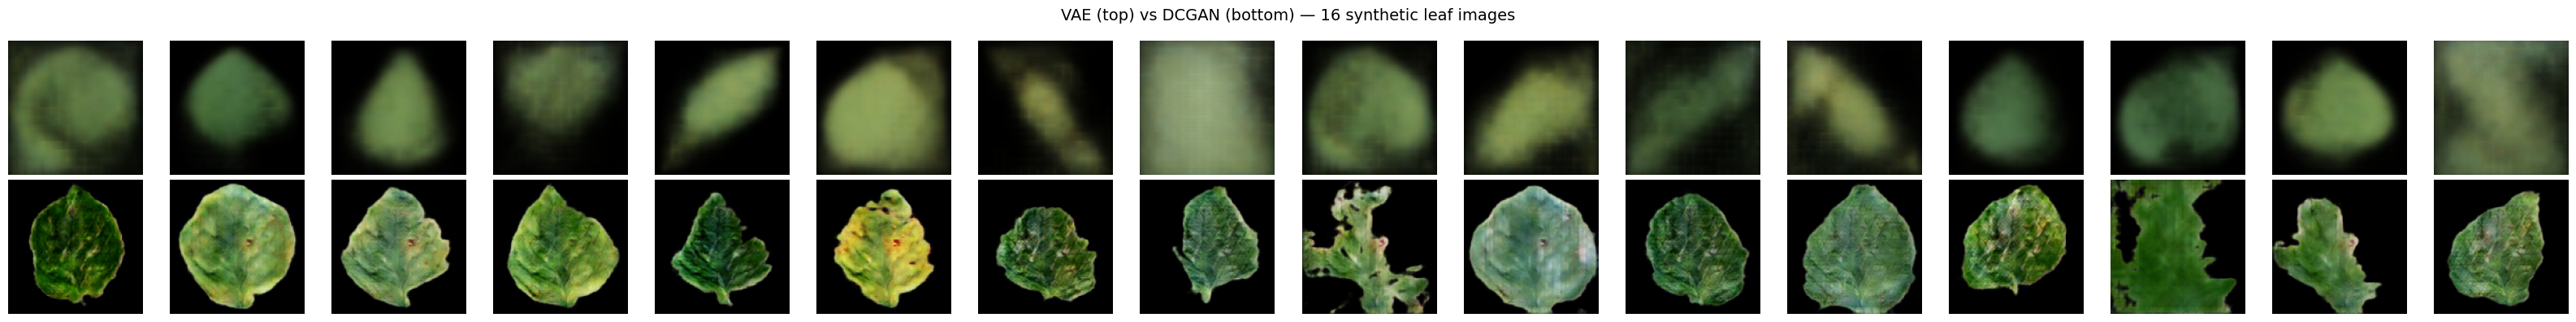

In [3]:
model_vae = VAE(128, 32).to(device)
model_vae.load_state_dict(torch.load('vae_model_weights.pth', map_location=device))
model_vae.eval()

model_gan = GAN(128, 128).to(device)
model_gan.load_state_dict(torch.load('gan_model_weights.pth', map_location=device))
model_gan.eval()

with torch.no_grad():
    grid_vae = model_vae.sample(16).permute(0, 2, 3, 1).cpu().numpy()
    grid_gan = model_gan.generate(16).permute(0, 2, 3, 1).cpu().numpy()

fig, axes = plt.subplots(2, 16, figsize=(32, 4))
fig.suptitle('VAE (top) vs DCGAN (bottom) — 16 synthetic leaf images', fontsize=14)
for i in range(16):
    axes[0, i].imshow(grid_vae[i].clip(0, 1))
    axes[0, i].axis('off')
    axes[1, i].imshow(grid_gan[i].clip(0, 1))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('VAE', fontsize=12)
axes[1, 0].set_ylabel('GAN', fontsize=12)
plt.tight_layout()
plt.savefig('P03_8.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Phase 3.9**: Frechet Inception Distance (FID)

In [ ]:
"""
This Cell is ran on server GPU. So not run here
"""

torch.manual_seed(42)
torch.mps.manual_seed(42)

model_gan_aptos = GAN(input_dim=128, latent_dim=128).to(device)
optimizer_G_aptos = torch.optim.Adam(model_gan_aptos.generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
optimizer_D_aptos = torch.optim.Adam(model_gan_aptos.discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

aptos_unlabeled_loader = DataLoader(UnlabeledDataset(aptos_gan), batch_size=32, shuffle=True)

g_losses_aptos, d_losses_aptos = GAN_training_loop(
    aptos_unlabeled_loader, model_gan_aptos,
    optimizer_G_aptos, optimizer_D_aptos,
    max_epoch=40
)

torch.save(model_gan_aptos.state_dict(), 'gan_aptos_model_weights.pth')


In [ ]:
inception = inception_v3(weights=Inception_V3_Weights.DEFAULT)
inception.fc = nn.Identity()
inception = inception.to(device)
inception.eval()

real_loader = DataLoader(Subset(aptos, range(min(500, len(aptos)))), batch_size=32, shuffle=False)

real_features = []
with torch.no_grad():
    for X in real_loader:
        X = X.to(device)
        real_features.append(inception(X).cpu().numpy())
real_features = np.concatenate(real_features, axis=0)[:500]
print(f'Real features shape: {real_features.shape}')


gan_resize = transforms.Resize((299, 299))
fake_features = []
model_gan_aptos = GAN(input_dim=128, latent_dim=128).to(device)
model_gan_aptos.load_state_dict(torch.load('gan_aptos_model_weights.pth', map_location=device))
with torch.no_grad():
    for start in range(0, 500, 32):
        B = min(32, 500 - start)
        fake = model_gan_aptos.generate(B)          
        fake = torch.stack([gan_resize(img) for img in fake])  
        fake_features.append(inception(fake.to(device)).cpu().numpy())
fake_features = np.concatenate(fake_features, axis=0)
print(f'Fake features shape: {fake_features.shape}')

fid_score = fid(real_features, fake_features)
print(f'FID Score: {fid_score:.4f}')


Real features shape: (295, 2048)
Fake features shape: (500, 2048)
FID Score: 384.2104


#### **Phase 3.10**: Batch Normalization & Mode Collapse

In [ ]:
"""
This Cell is ran on server GPU. So not run here
"""

torch.manual_seed(42)
torch.mps.manual_seed(42)

model_gan_aptos = GAN(input_dim=128, latent_dim=128).to(device)

for i, layer in enumerate(model_gan_aptos.generator):
    if isinstance(layer, nn.BatchNorm2d):
        model_gan_aptos.generator[i] = nn.Identity()

optimizer_G_aptos = torch.optim.Adam(model_gan_aptos.generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
optimizer_D_aptos = torch.optim.Adam(model_gan_aptos.discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

aptos_unlabeled_loader = DataLoader(UnlabeledDataset(aptos_gan), batch_size=32, shuffle=True)

g_losses_aptos, d_losses_aptos = GAN_training_loop(
    aptos_unlabeled_loader, model_gan_aptos,
    optimizer_G_aptos, optimizer_D_aptos,
    max_epoch=40
)

torch.save(model_gan_aptos.state_dict(), 'gan_aptos_model_woBN_weights.pth')

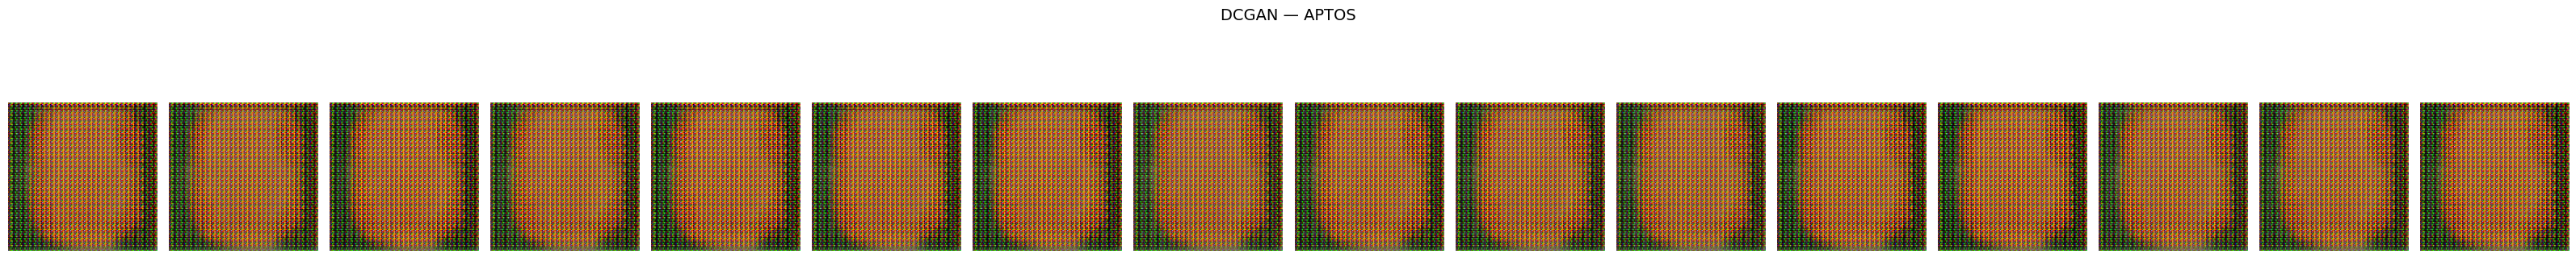

In [19]:
model_gan_aptos = GAN(input_dim=128, latent_dim=128).to(device)
for i, layer in enumerate(model_gan_aptos.generator):
    if isinstance(layer, nn.BatchNorm2d):
        model_gan_aptos.generator[i] = nn.Identity()
model_gan_aptos.load_state_dict(torch.load("gan_aptos_model_woBN_weights.pth", map_location=device))

with torch.no_grad():
    grid_gan = model_gan_aptos.generate(16).permute(0, 2, 3, 1).cpu().numpy()

fig, axes = plt.subplots(1, 16, figsize=(32, 4))
fig.suptitle('DCGAN — APTOS', fontsize=14)
for i in range(16):
    axes[i].imshow(grid_gan[i].clip(0, 1))
    axes[i].axis('off')
axes[0].set_ylabel('GAN', fontsize=12)
plt.tight_layout()
plt.savefig('P03_10.png', dpi=150, bbox_inches='tight')
plt.show()

### **Phase 4**: Self-Supervised Learning via SimCLR (PlantVillage)

In [10]:
DATA_DIR = "/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data"

transform = transforms.Resize((128, 128))
plantvillage = PlantVillageDataset(os.path.join(DATA_DIR, 'plantvillage_dataset/segmented'), transform=transform)

#### **Phase 4.11**: InfoNCE Loss

In [ ]:
"""
This Cell is ran on server GPU. So not run here
"""

torch.mps.manual_seed(42)
torch.manual_seed(42)
np.random.seed(42)

unlabeled_dataset = UnlabeledDataset(plantvillage)
N = len(unlabeled_dataset)
idx = np.random.permutation(N)

train_idx = idx[:int(0.85*N)]
val_idx = idx[int(0.85*N):]

train_dataset = Subset(unlabeled_dataset, train_idx)
val_dataset = Subset(unlabeled_dataset, val_idx)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=True)

transform1 = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
])
transform2 = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
])
model_simclr = SimCLR(512, transform1, transform2)
optimizer = torch.optim.Adam(model_simclr.parameters(), lr=1e-3)

train_final_loss, val_final_loss = SimCLRtraining_loop(train_dataloader, val_dataloader, model_simclr, optimizer, max_epoch=30)

torch.save(model_simclr.state_dict(), 'simclr_model.pth')

#### **Phase 4.12**: The Linear Evaluation Protocol

In [ ]:
"""
This Cell is ran on server GPU. So not run here
"""

model_simclr_eval = SimCLR(512, transforms.Compose([]), transforms.Compose([]))
model_simclr_eval.load_state_dict(torch.load('simclr_model.pth', map_location=device))
model_simclr_eval = model_simclr_eval.to(device)
for param in model_simclr_eval.parameters():
    param.requires_grad = False

np.random.seed(42)
N_pv = len(plantvillage)
pv_idx = np.random.permutation(N_pv)
pv_train_loader = DataLoader(Subset(plantvillage, pv_idx[:int(0.7*N_pv)]),                batch_size=64, shuffle=True)
pv_val_loader   = DataLoader(Subset(plantvillage, pv_idx[int(0.7*N_pv):int(0.85*N_pv)]), batch_size=64)
pv_test_loader  = DataLoader(Subset(plantvillage, pv_idx[int(0.85*N_pv):]),              batch_size=64)

n_classes = len(plantvillage.class_to_idx)
probe = LinearProbe(model_simclr_eval.resnet18, latent_dim=512, n_classes=n_classes).to(device)

optimizer_lin = torch.optim.Adam(probe.head.parameters(), lr=1e-3)
ce_loss = nn.CrossEntropyLoss()

train_loop(pv_train_loader, pv_val_loader, probe, ce_loss, optimizer_lin, max_epoch=30)

torch.save(model_simclr.state_dict(), 'simclr_model_linear_classification.pth')

In [13]:
np.random.seed(42)
N_pv = len(plantvillage)
pv_idx = np.random.permutation(N_pv)
pv_train_loader = DataLoader(Subset(plantvillage, pv_idx[:int(0.7*N_pv)]),                batch_size=32, shuffle=True)
pv_val_loader   = DataLoader(Subset(plantvillage, pv_idx[int(0.7*N_pv):int(0.85*N_pv)]), batch_size=32)
pv_test_loader  = DataLoader(Subset(plantvillage, pv_idx[int(0.85*N_pv):]),              batch_size=32)

n_classes = len(plantvillage.class_to_idx)
ce_loss = nn.CrossEntropyLoss()

model_CNN = ownCNN(128, len(plantvillage.class_to_idx)).to(device)
model_CNN.load_state_dict(torch.load("cnn_model_weights.pth", map_location=device))

model_simclr_eval = SimCLR(512, transforms.Compose([]), transforms.Compose([]))
model_simclr_eval.load_state_dict(torch.load('simclr_model.pth', map_location=device))
probe = LinearProbe(model_simclr_eval.resnet18, latent_dim=512, n_classes=n_classes).to(device)
probe.load_state_dict(torch.load('simclr_model_linear_classification.pth', map_location = device))

test_loop(pv_test_loader, probe, ce_loss)
test_loop(pv_test_loader, model_CNN, ce_loss)

Test Loss: 11.9454
Test Loss: 0.2865


### **Phase 5**: Policy Gradient Theorem (Air Quality RL)

In [2]:
DATA_DIR = "/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data"
time_series_file_path = os.path.join(DATA_DIR, 'delhi_aqi.csv')

data_regression = TimeSeriesDataset(time_series_file_path, 24,0, all_features=True)

#### **Phase 5.13**: Policy Gradient Theorem (Air Quality RL)

Epoch: 0 done!
Epoch: 1 done!
Epoch: 2 done!
Epoch: 3 done!
Epoch: 4 done!
Epoch: 5 done!
Epoch: 6 done!
Epoch: 7 done!
Epoch: 8 done!
Epoch: 9 done!
Epoch: 10 done!
Epoch: 11 done!
Epoch: 12 done!
Epoch: 13 done!
Epoch: 14 done!
Epoch: 15 done!
Epoch: 16 done!
Epoch: 17 done!
Epoch: 18 done!
Epoch: 19 done!
Epoch: 20 done!
Epoch: 21 done!
Epoch: 22 done!
Epoch: 23 done!
Epoch: 24 done!
Epoch: 25 done!
Epoch: 26 done!
Epoch: 27 done!
Epoch: 28 done!
Epoch: 29 done!
Epoch: 30 done!
Epoch: 31 done!
Epoch: 32 done!
Epoch: 33 done!
Epoch: 34 done!
Epoch: 35 done!
Epoch: 36 done!
Epoch: 37 done!
Epoch: 38 done!
Epoch: 39 done!
Epoch: 40 done!
Epoch: 41 done!
Epoch: 42 done!
Epoch: 43 done!
Epoch: 44 done!
Epoch: 45 done!
Epoch: 46 done!
Epoch: 47 done!
Epoch: 48 done!
Epoch: 49 done!
Epoch: 50 done!
Epoch: 51 done!
Epoch: 52 done!
Epoch: 53 done!
Epoch: 54 done!
Epoch: 55 done!
Epoch: 56 done!
Epoch: 57 done!
Epoch: 58 done!
Epoch: 59 done!
Epoch: 60 done!
Epoch: 61 done!
Epoch: 62 done!
Ep

/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_11829/1027037410.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


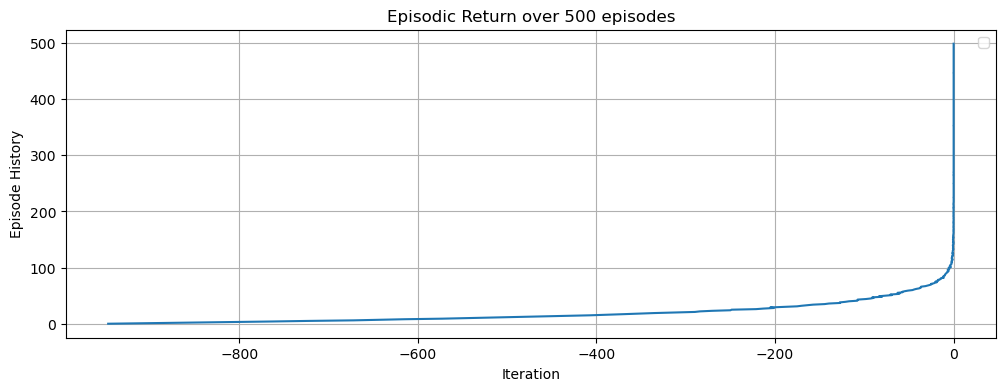

In [ ]:
policy_net = PolicyNetwork(input_dim=192) 
optimizer = torch.optim.Adam(policy_net.parameters(), lr=1e-3)
episode_history = []

for episode in range(500):
    log_probs, rewards = collect_trajectory(policy_net, data_regression.X, data_regression.y)
    update_policy(optimizer, log_probs, rewards)
    
    total_return = sum(rewards)
    episode_history.append(total_return)
    print(f"Epoch: {episode} done!")

/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_11829/2968033966.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


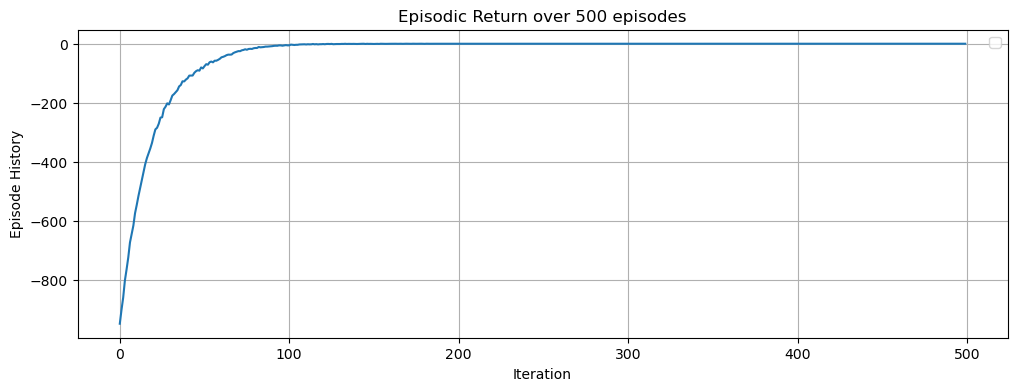

In [8]:
plt.figure(figsize=(12,4))
plt.plot(np.arange(500), episode_history )
plt.xlabel('Iteration')
plt.ylabel('Episode History')
plt.title('Episodic Return over 500 episodes')
plt.legend()
plt.grid()
plt.savefig("P05_13.png")
plt.show()